In [2]:
from sklearn.datasets import fetch_covtype
import pandas as pd

# Load the dataset
covtype = fetch_covtype(as_frame=True)  # Returns a DataFrame
X = covtype.data  # Features
y = covtype.target - 1  # Target (adjusted to 0-6 for zero-based indexing)

In [3]:
sample_size = 20000
# Ensure we get a balanced sample across all classes
from sklearn.model_selection import train_test_split
X_sample, _, y_sample, _ = train_test_split(
    X, y, train_size=sample_size, random_state=42, stratify=y
)
X = X_sample
y = y_sample

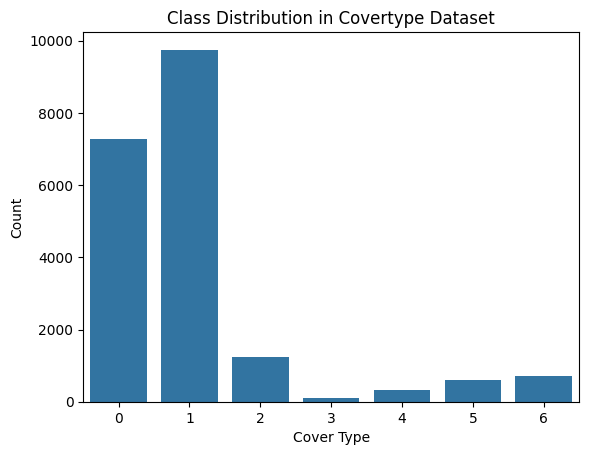

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=y)
plt.title('Class Distribution in Covertype Dataset')
plt.xlabel('Cover Type')
plt.ylabel('Count')
plt.show()

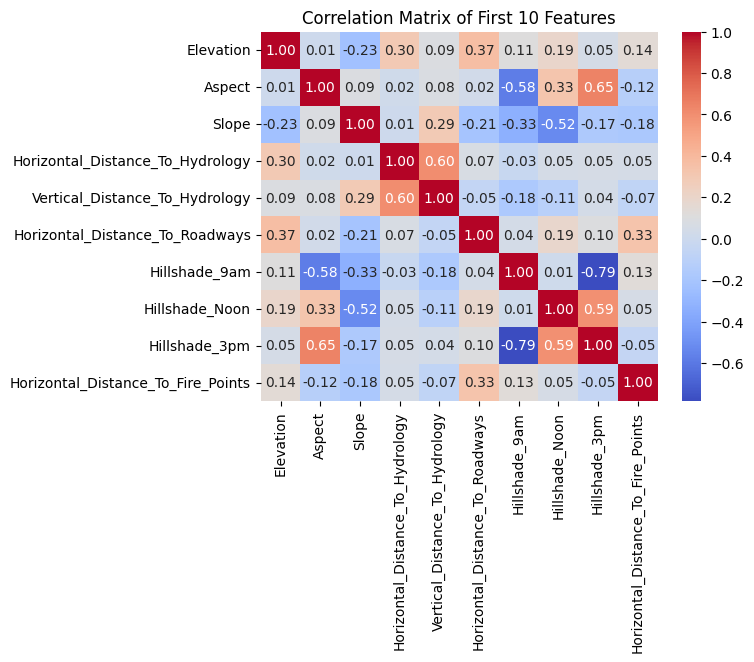

In [5]:
# Select first 10 features for simplicity
subset = X.iloc[:, :10]

# Compute correlation matrix
corr = subset.corr()

# Plot heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of First 10 Features')
plt.show()

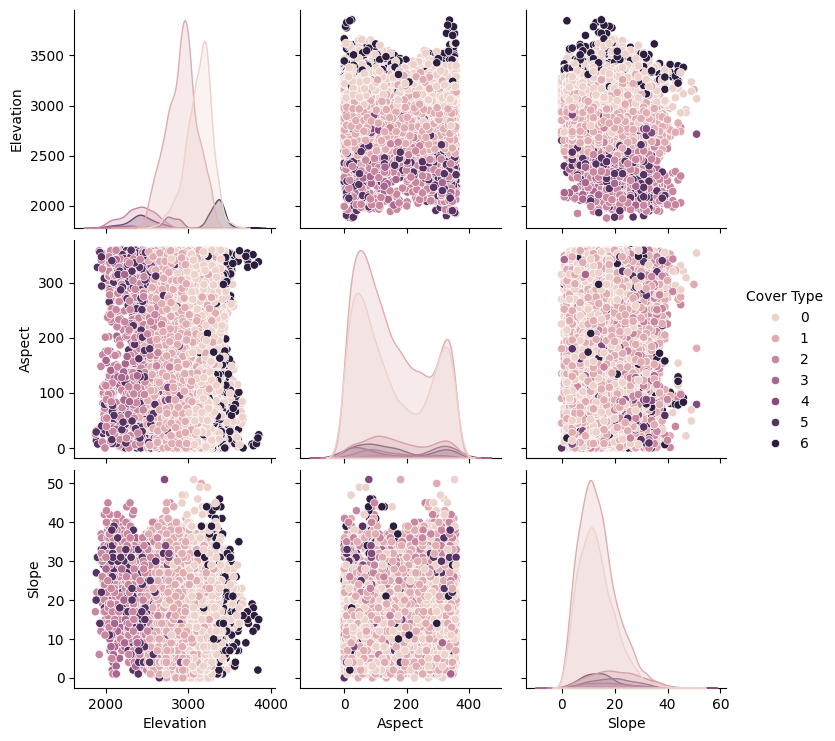

In [6]:
# Combine features and target for a sample
sample = X.iloc[:, :3].copy()  # First 3 features
sample['Cover Type'] = y

sns.pairplot(sample, hue='Cover Type', diag_kind='kde')
plt.show()

In [8]:
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Split the dataset into training, validation and testing sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Initialize the CatBoost model with default settings
model = CatBoostClassifier(verbose=0, random_state=42)

# Train the model
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate accuracy
baseline_accuracy = accuracy_score(y_test, y_pred)

print(f"Baseline Accuracy: {baseline_accuracy * 100:.2f}%")

Baseline Accuracy: 83.43%


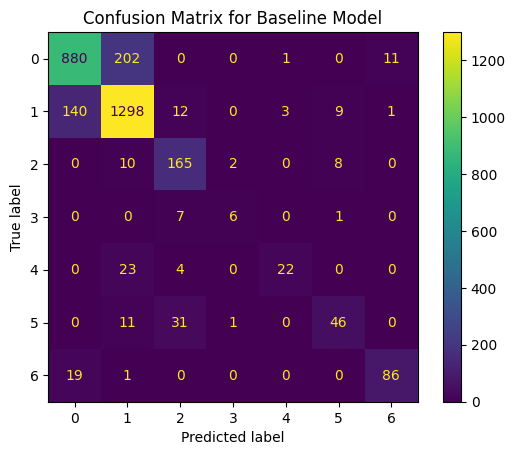

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
plt.title('Confusion Matrix for Baseline Model')
plt.show()

In [10]:
import optuna
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score

def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.1),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-8, 10.0),
        'grow_policy': trial.suggest_categorical('grow_policy', ['Depthwise', 'Lossguide', 'SymmetricTree']),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 20)
    }

    model = CatBoostClassifier(**params, verbose=0, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    return accuracy

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)

trial = study.best_trial

print("Accuracy: {}".format(trial.value))
print("Best hyperparameters: {}".format(trial.params))

    # TODO:
    # 1. Train CatBoost using params
    # 2. Return validation accuracy score as result
    # Area for improvement: use Cross-Validation instead of a single train/val split.

[I 2025-04-01 07:02:28,336] A new study created in memory with name: no-name-0e9e39f5-346c-4b5d-bea5-945ff5917e15
[I 2025-04-01 07:02:50,093] Trial 0 finished with value: 0.806 and parameters: {'iterations': 519, 'learning_rate': 0.05410194203956667, 'depth': 7, 'l2_leaf_reg': 0.6695140462934475, 'grow_policy': 'Lossguide', 'min_data_in_leaf': 5}. Best is trial 0 with value: 0.806.
[I 2025-04-01 07:03:20,537] Trial 1 finished with value: 0.7616666666666667 and parameters: {'iterations': 714, 'learning_rate': 0.015056975806167407, 'depth': 5, 'l2_leaf_reg': 1.063346266034807, 'grow_policy': 'Lossguide', 'min_data_in_leaf': 1}. Best is trial 0 with value: 0.806.
[I 2025-04-01 07:05:16,559] Trial 2 finished with value: 0.8396666666666667 and parameters: {'iterations': 773, 'learning_rate': 0.0966911428128971, 'depth': 9, 'l2_leaf_reg': 8.212423322832315, 'grow_policy': 'SymmetricTree', 'min_data_in_leaf': 3}. Best is trial 2 with value: 0.8396666666666667.
[I 2025-04-01 07:05:45,869] Tria

Accuracy: 0.8573333333333333
Best hyperparameters: {'iterations': 893, 'learning_rate': 0.08300615558584774, 'depth': 10, 'l2_leaf_reg': 0.947518407380195, 'grow_policy': 'SymmetricTree', 'min_data_in_leaf': 15}


In [11]:
# Retrieve the best trial from the study
best_trial = study.best_trial

print(f"Best Trial Number: {best_trial.number}")
print(f"Best Validation Accuracy: {best_trial.value:.4f}")
print("Best Hyperparameters Found:")
for key, value in best_trial.params.items():
    print(f"  {key}: {value}")

Best Trial Number: 77
Best Validation Accuracy: 0.8573
Best Hyperparameters Found:
  iterations: 893
  learning_rate: 0.08300615558584774
  depth: 10
  l2_leaf_reg: 0.947518407380195
  grow_policy: SymmetricTree
  min_data_in_leaf: 15


In [13]:
best_params = best_trial.params

# --- IMPORTANT: Combine Training and Validation Data ---
# Create the full training dataset (train + validation) for the final model
X_train_full = pd.concat([X_train, X_valid], ignore_index=True)
y_train_full = pd.concat([y_train, y_valid], ignore_index=True)

final_params = best_params.copy()
final_params['random_state'] = 42

final_model = CatBoostClassifier(**final_params)
final_model.fit(X_train_full, y_train_full)

0:	learn: 1.7337812	total: 388ms	remaining: 5m 46s
1:	learn: 1.5790105	total: 711ms	remaining: 5m 16s
2:	learn: 1.4511087	total: 992ms	remaining: 4m 54s
3:	learn: 1.3521520	total: 1.36s	remaining: 5m 1s
4:	learn: 1.2678716	total: 1.71s	remaining: 5m 3s
5:	learn: 1.1953954	total: 2.11s	remaining: 5m 12s
6:	learn: 1.1338789	total: 2.48s	remaining: 5m 13s
7:	learn: 1.0794262	total: 2.84s	remaining: 5m 14s
8:	learn: 1.0319754	total: 3.29s	remaining: 5m 22s
9:	learn: 0.9930731	total: 3.64s	remaining: 5m 21s
10:	learn: 0.9557687	total: 4s	remaining: 5m 20s
11:	learn: 0.9227337	total: 4.35s	remaining: 5m 19s
12:	learn: 0.8927702	total: 4.69s	remaining: 5m 17s
13:	learn: 0.8661610	total: 5.05s	remaining: 5m 16s
14:	learn: 0.8411201	total: 5.4s	remaining: 5m 16s
15:	learn: 0.8184286	total: 5.74s	remaining: 5m 14s
16:	learn: 0.7978032	total: 6.12s	remaining: 5m 15s
17:	learn: 0.7791592	total: 6.5s	remaining: 5m 16s
18:	learn: 0.7599067	total: 6.76s	remaining: 5m 10s
19:	learn: 0.7450604	total: 6

--- Performance Comparison ---
Baseline Accuracy (on Test Set): 83.43%
Optimized Accuracy (on Test Set): 85.70%
Improvement due to HPO: 2.27%
Confusion Matrix for Final Optimized Model (on Test Set):


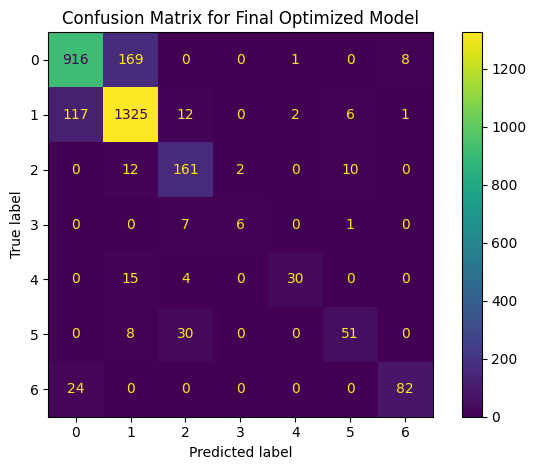

In [14]:
y_pred_test = final_model.predict(X_test)

# Calculate final accuracy
final_accuracy = accuracy_score(y_test, y_pred_test)

print("--- Performance Comparison ---")
# Assuming baseline_accuracy variable holds the score from Step 5
print(f"Baseline Accuracy (on Test Set): {baseline_accuracy * 100:.2f}%")
print(f"Optimized Accuracy (on Test Set): {final_accuracy * 100:.2f}%")
improvement = final_accuracy - baseline_accuracy
print(f"Improvement due to HPO: {improvement * 100:.2f}%")

print("Confusion Matrix for Final Optimized Model (on Test Set):")
ConfusionMatrixDisplay.from_estimator(final_model, X_test, y_test)
plt.title('Confusion Matrix for Final Optimized Model')
plt.tight_layout()
plt.show()

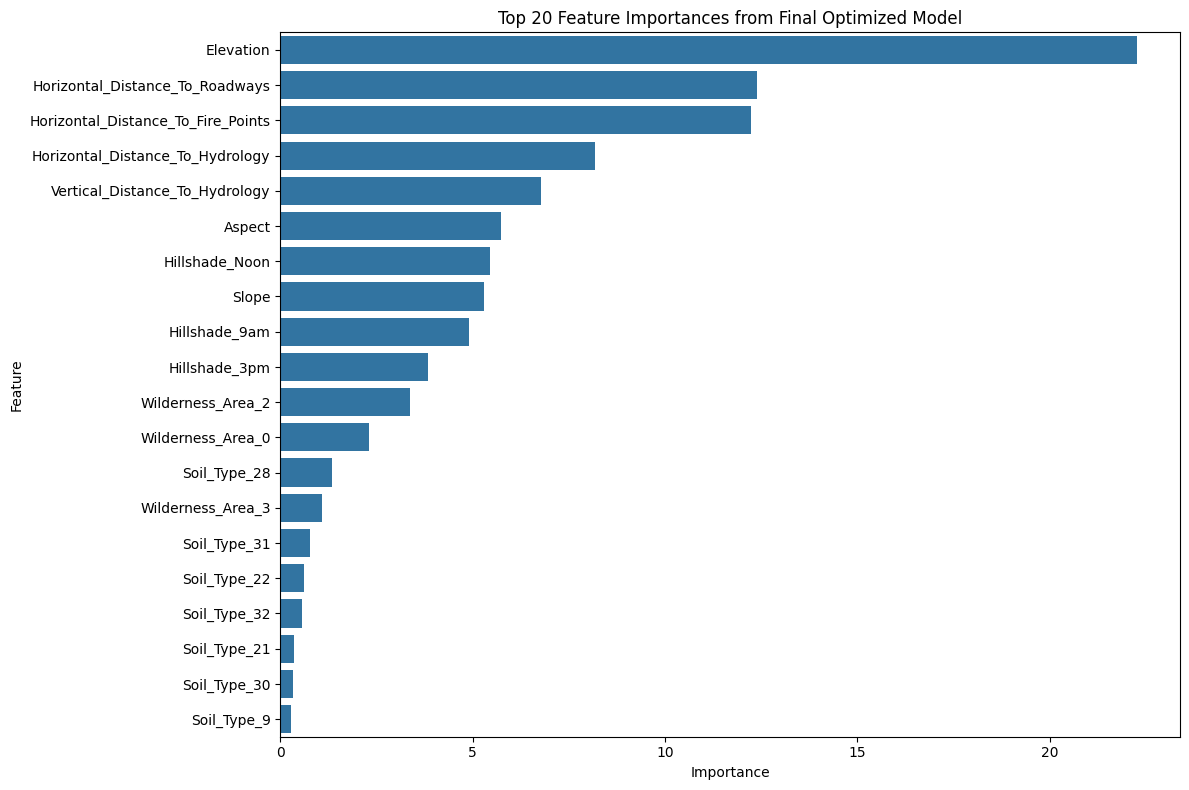

In [15]:
importances = final_model.get_feature_importance()
feature_names = X_train_full.columns

# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot feature importances (e.g., top 20)
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20)) # Plot top 20
plt.title('Top 20 Feature Importances from Final Optimized Model')
plt.tight_layout()
plt.show()